# 예제 2: 불량 예측 AI 만들기 (Random Forest)

---

## 이 예제에서 배울 것
- **머신러닝의 핵심 개념**: 학습 데이터 → 모델 학습 → 새 데이터 예측
- **Random Forest**: 가장 널리 쓰이는 AI 알고리즘 중 하나 (결정 나무 여러 개의 조합)
- **성능 평가**: AI가 얼마나 잘 맞추는지 수치로 확인하는 방법

## 핵심 메시지
> **"AI는 과거 데이터의 패턴을 학습하여 미래를 예측한다."**  
> 온도, 압력, 속도 데이터를 보고 '이 조건에서 불량이 날까?'를 AI가 판단합니다.

## 제조 현장 연관
- 공정 조건 입력 → AI가 불량 가능성 사전 경보
- **예방 품질 관리**: 불량이 발생하기 전에 조건 조정
- **KPI**: 불량 검출률(Recall) ≥ 90% 이상이 실용적 기준

## 머신러닝 동작 원리 (개념)

```
학습 단계 (Training)
과거 데이터 (온도, 압력, 속도) + 정답 (불량/정상)
        ↓
  AI 모델이 "패턴" 학습
  예: "온도 > 90도이면 불량 확률 높다"

예측 단계 (Prediction)
새로운 데이터 (온도, 압력, 속도)
        ↓
  AI 모델이 패턴을 적용
        ↓
  결과: "불량" 또는 "정상" 예측
```

**Random Forest란?**
- '결정 나무(Decision Tree)' 수백 개를 만들어 **다수결 투표**로 결정
- 마치 의사 한 명의 판단보다 **전문가 100명의 다수결**이 더 정확한 것과 같음

In [1]:
# ─────────────────────────────────────────────────────────
# 필요한 도구 불러오기
# sklearn(scikit-learn): 머신러닝 알고리즘을 모아놓은 대표적인 라이브러리
# ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

# sklearn에서 필요한 모듈만 골라서 가져오기
from sklearn.ensemble import RandomForestClassifier  # 랜덤 포레스트 모델
from sklearn.model_selection import train_test_split  # 데이터 분할 도구
from sklearn.metrics import classification_report, confusion_matrix  # 성능 평가 도구

import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 숨기기 (실습 환경 정리용)

print("모든 도구 준비 완료!")

모든 도구 준비 완료!


## STEP 1: 학습용 데이터 생성

In [2]:
# ─────────────────────────────────────────────────────────
# 불량 발생 규칙을 알고 있는 가상 데이터 생성
# (실제 현장에서는 이 규칙을 AI가 스스로 발견합니다)
#
# 불량 발생 조건:
#   - 온도 > 90°C 이면 불량 확률 +30%
#   - 압력 < 2.0 MPa 이면 불량 확률 +25%
#   - 속도 > 140 rpm 이면 불량 확률 +15%
# ─────────────────────────────────────────────────────────
np.random.seed(42)
n = 1000  # 1000건의 과거 공정 기록

# 공정 조건 데이터 생성
온도   = np.random.normal(85, 8, n)    # 평균 85도, 표준편차 8
압력   = np.random.normal(2.5, 0.4, n) # 평균 2.5MPa, 표준편차 0.4
속도   = np.random.normal(120, 15, n)  # 평균 120rpm, 표준편차 15
경력   = np.random.choice([1, 3, 5, 10, 15], n)  # 작업자 경력(년)

# ─────────────────────────────────────────────────────────
# 불량 여부 결정 (이것이 AI의 '정답 레이블'이 됩니다)
# 각 조건에 따라 불량 확률 합산
# ─────────────────────────────────────────────────────────
불량_확률 = (
    0.05                         # 기본 불량률 5% (어떤 조건에서도 발생)
    + (온도 > 90).astype(float) * 0.30   # 고온 조건: 30% 추가
    + (압력 < 2.0).astype(float) * 0.25  # 저압 조건: 25% 추가
    + (속도 > 140).astype(float) * 0.15  # 고속 조건: 15% 추가
)
# astype(float): True/False를 1.0/0.0으로 변환

# np.random.random(n): 0~1 사이 랜덤 숫자 생성
# 랜덤 숫자 < 불량_확률 이면 불량 발생 (확률적 시뮬레이션)
불량여부 = (np.random.random(n) < 불량_확률).astype(int)  # 0=정상, 1=불량

# DataFrame으로 묶기
df = pd.DataFrame({
    '온도':   온도,
    '압력':   압력,
    '속도':   속도,
    '경력':   경력,
    '불량여부': 불량여부  # 0=정상, 1=불량 (AI의 학습 정답)
})

print(f" 데이터 생성 완료: 총 {n}건")
print(f"   정상(0): {(불량여부 == 0).sum()}건")
print(f"   불량(1): {(불량여부 == 1).sum()}건")
print(f"   불량률: {불량여부.mean() * 100:.1f}%")

print("\n 데이터 미리보기:")
df.head()

 데이터 생성 완료: 총 1000건
   정상(0): 834건
   불량(1): 166건
   불량률: 16.6%

 데이터 미리보기:


,온도,압력,속도,경력,불량여부
0,88.973713,3.059742,109.872326,10,0
1,83.893886,2.869853,117.832220,3,0
2,90.181508,2.523852,108.113701,1,1
3,97.184239,2.241225,115.380577,3,1
4,83.126773,2.779289,91.595780,15,0


## STEP 2: 데이터를 '학습용'과 '시험용'으로 분리

AI 교육도 학교 교육과 비슷합니다:
- **학습 데이터 (80%)**: 교과서처럼 AI가 공부하는 데이터
- **테스트 데이터 (20%)**: 시험지처럼 AI가 못 본 데이터로 실력 검증

**주의**: 시험 문제(테스트 데이터)를 공부할 때 미리 보여주면 안 됩니다!

In [4]:
# ─────────────────────────────────────────────────────────
# 특성(Feature)과 정답(Label) 분리
# X: 입력 변수 (AI가 보고 판단하는 정보)
# y: 정답 (불량=1, 정상=0)
# ─────────────────────────────────────────────────────────
X = df[['온도', '압력', '속도', '경력']]  # 특성(Feature): 공정 조건 4가지
y = df['불량여부']                         # 정답(Label): 실제 불량 여부

print("입력 변수 (X):")
print(X.head(3))
print("\n정답 레이블 (y):")
print(y.head(3).to_string())

# ─────────────────────────────────────────────────────────
# train_test_split: 데이터를 학습/테스트로 자동 분할
# test_size=0.2: 20%는 테스트용, 80%는 학습용
# random_state=42: 같은 방식으로 분할 (재현 가능하도록)
# ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% = 테스트용
    random_state=42     # 분할 방식 고정
)

print(f"\n✅ 데이터 분할 완료!")
print(f"   학습 데이터: {len(X_train)}건 (80%)")
print(f"   테스트 데이터: {len(X_test)}건 (20%)")

입력 변수 (X):
          온도        압력          속도  경력
0  88.973713  3.059742  109.872326  10
1  83.893886  2.869853  117.832220   3
2  90.181508  2.523852  108.113701   1

정답 레이블 (y):
0    0
1    0
2    1

✅ 데이터 분할 완료!
   학습 데이터: 800건 (80%)
   테스트 데이터: 200건 (20%)


## STEP 3: AI 모델 학습 (Training)

이제 AI에게 '공부'를 시킵니다.  
단 2줄의 코드로 머신러닝 모델이 완성됩니다!

In [5]:
# ─────────────────────────────────────────────────────────
# Random Forest 모델 생성 및 학습
#
# RandomForestClassifier: 분류(Classification) 문제에 사용
#   - '분류': 데이터를 카테고리(정상/불량)로 나누는 것
#
# n_estimators=100: 결정 나무(Decision Tree)를 100개 만들어 다수결
#   → 나무가 많을수록 정확하지만 시간이 오래 걸림 (100개가 일반적)
# random_state=42: 학습 결과 고정 (같은 결과 재현 가능)
# ─────────────────────────────────────────────────────────
print("AI 모델 학습 중...")

model = RandomForestClassifier(
    n_estimators=100,   # 결정 나무 100개
    random_state=42     # 재현 가능성을 위한 시드
)

# fit(): 학습 함수 - X(입력)와 y(정답)를 보여주며 패턴 학습
model.fit(X_train, y_train)

print("학습 완료!")
print(f"   결정 나무 {model.n_estimators}개가 협력하여 예측합니다.")

AI 모델 학습 중...
학습 완료!
   결정 나무 100개가 협력하여 예측합니다.


## STEP 4: 성능 평가 — AI가 얼마나 잘 맞추나?

**혼동 행렬 (Confusion Matrix)** 이해하기:
```
               AI 예측
              정상  불량
실제  정상  [  ✅   ❌  ]  → ❌: 정상인데 불량으로 예측 (과잉 경보)
      불량  [  ❌   ✅  ]  → ❌: 불량인데 정상으로 예측 (위험! 불량 유출)
```

**제조 품질에서 가장 중요한 지표: 재현율(Recall)**
- 실제 불량 중 AI가 찾아낸 비율
- **높을수록 좋음** (놓치는 불량이 적음 = 불량 유출 방지)

In [8]:
# ─────────────────────────────────────────────────────────
# 테스트 데이터로 예측 (AI가 공부 안 한 새 시험 문제)
# predict(): 학습된 모델로 예측
# ─────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

print("=" * 55)
print("AI 모델 성능 평가 결과")
print("=" * 55)

# classification_report: 정밀도/재현율/F1 등 종합 성능 표 출력
print(classification_report(
    y_test, y_pred,
    target_names=['정상(0)', '불량(1)'],  # 클래스 이름 지정
    zero_division=0  # 0으로 나누는 오류 방지
))

print("\n 용어 설명:")
print("  precision(정밀도): AI가 '불량'이라고 예측했을 때 실제로 불량일 확률")
print("  recall(재현율): 실제 불량 중 AI가 잡아낸 비율 → 제조업에서 가장 중요!")
print("  f1-score: 정밀도와 재현율의 균형 지표")
print("  support: 실제 데이터 개수")

AI 모델 성능 평가 결과
              precision    recall  f1-score   support

       정상(0)       0.87      0.95      0.91       169
       불량(1)       0.44      0.23      0.30        31

    accuracy                           0.83       200
   macro avg       0.65      0.59      0.60       200
weighted avg       0.80      0.83      0.81       200


 용어 설명:
  precision(정밀도): AI가 '불량'이라고 예측했을 때 실제로 불량일 확률
  recall(재현율): 실제 불량 중 AI가 잡아낸 비율 → 제조업에서 가장 중요!
  f1-score: 정밀도와 재현율의 균형 지표
  support: 실제 데이터 개수


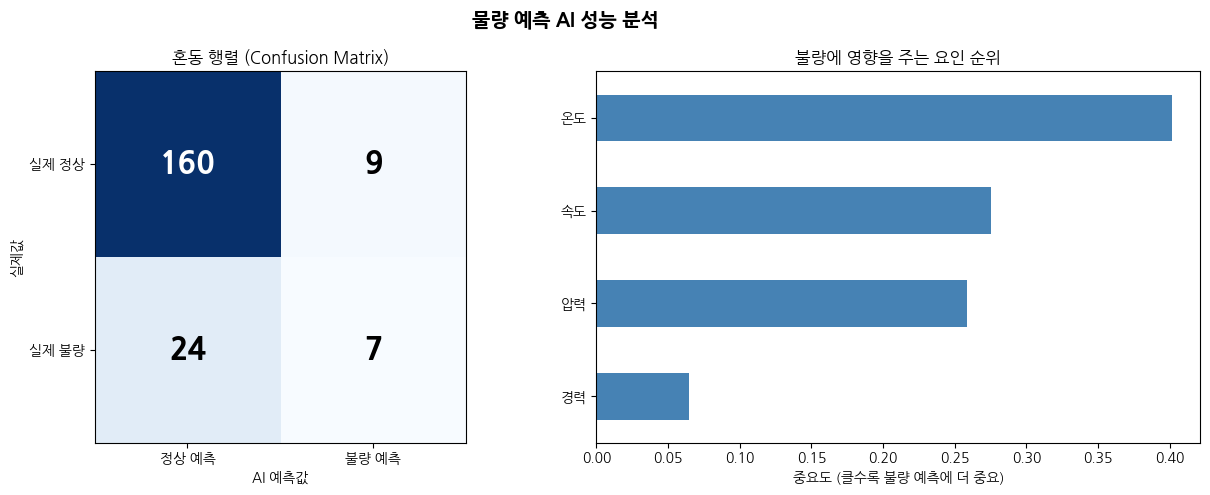


 해석:
  변수 중요도 1위: 온도
  → '온도' 조건이 불량 발생에 가장 큰 영향을 미칩니다


In [10]:
# ─────────────────────────────────────────────────────────
# 시각화: 혼동 행렬 + 변수 중요도
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('불량 예측 AI 성능 분석', fontsize=14, fontweight='bold')

# ─── 혼동 행렬 시각화 ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

# imshow: 2차원 배열을 색상으로 표현
axes[0].imshow(cm, cmap='Blues')  # Blues: 파란색 계열 색상 맵
axes[0].set_title('혼동 행렬 (Confusion Matrix)', fontsize=12)
axes[0].set_xlabel('AI 예측값')
axes[0].set_ylabel('실제값')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['정상 예측', '불량 예측'])
axes[0].set_yticklabels(['실제 정상', '실제 불량'])

# 각 칸에 숫자 표시
for i in range(2):
    for j in range(2):
        # 배경이 어두우면 흰색, 밝으면 검은색 글자 사용
        글자색 = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        axes[0].text(
            j, i,           # x, y 좌표
            cm[i, j],       # 표시할 숫자
            ha='center', va='center',
            fontsize=22, fontweight='bold',
            color=글자색
        )

# ─── 변수 중요도 (Feature Importance) 시각화 ──────────────
# feature_importances_: 각 변수가 예측에 얼마나 기여하는지
중요도 = pd.Series(
    model.feature_importances_,
    index=['온도', '압력', '속도', '경력']  # 변수 이름 매핑
)

# sort_values(): 값 기준으로 정렬
중요도.sort_values().plot(
    kind='barh',          # 'barh' = 가로 막대그래프
    ax=axes[1],
    color='steelblue'
)
axes[1].set_title('불량에 영향을 주는 요인 순위', fontsize=12)
axes[1].set_xlabel('중요도 (클수록 불량 예측에 더 중요)')

plt.tight_layout()
plt.show()

print("\n 해석:")
print("  변수 중요도 1위:", 중요도.idxmax())
print(f"  → '{중요도.idxmax()}' 조건이 불량 발생에 가장 큰 영향을 미칩니다")

## STEP 5: 실제 활용 — 새 공정 조건으로 예측하기

학습된 AI 모델로 **현재 공정 조건**을 입력하면 불량 가능성을 즉시 확인할 수 있습니다.

In [11]:
# ─────────────────────────────────────────────────────────
# 새로운 공정 조건 3가지를 AI에게 예측 요청
# (실제 현장에서는 MES에서 실시간 데이터를 가져와 예측)
# ─────────────────────────────────────────────────────────
새_데이터 = pd.DataFrame({
    '온도':  [82,  95,  88],   # 조건1: 정상 / 조건2: 고온 / 조건3: 보통
    '압력':  [2.6, 1.8, 2.4],  # 조건1: 정상 / 조건2: 저압 / 조건3: 정상
    '속도':  [115, 145, 122],  # 조건1: 정상 / 조건2: 고속 / 조건3: 정상
    '경력':  [10,  1,   5]     # 조건1: 숙련 / 조건2: 신입 / 조건3: 중간
})

# predict(): 정상(0) 또는 불량(1) 예측
예측_결과 = model.predict(새_데이터)

# predict_proba(): 각 클래스(정상/불량)의 확률 예측
# 결과: [[정상확률, 불량확률], [정상확률, 불량확률], ...]
예측_확률 = model.predict_proba(새_데이터)

print("=" * 60)
print("새 공정 조건 불량 예측 결과")
print("=" * 60)

상황설명 = ['정상 조건', '고온+저압+고속+신입', '일반 조건']

for i, (row_idx, row) in enumerate(새_데이터.iterrows()):
    # iterrows(): DataFrame의 각 행을 순서대로 꺼냄
    판정 = " 불량 위험!" if 예측_결과[i] == 1 else "🟢 정상"
    불량확률 = 예측_확률[i][1] * 100  # 불량 확률 (1번 인덱스)
    
    print(f"\n[조건 {i+1}] {상황설명[i]}")
    print(f"  입력: 온도={row['온도']:.0f}°C, 압력={row['압력']:.1f}MPa, "
          f"속도={row['속도']:.0f}rpm, 경력={row['경력']:.0f}년")
    print(f"  결과: {판정} (불량 확률: {불량확률:.0f}%)")

print("\n" + "=" * 60)
print(" 실제 현장 적용 시")
print("  불량 확률 50% 이상 → 경보 발생 + 공정 조건 점검 권고")
print("  불량 확률 80% 이상 → 즉시 정지 + 원인 조사")

새 공정 조건 불량 예측 결과

[조건 1] 정상 조건
  입력: 온도=82°C, 압력=2.6MPa, 속도=115rpm, 경력=10년
  결과: 🟢 정상 (불량 확률: 1%)

[조건 2] 고온+저압+고속+신입
  입력: 온도=95°C, 압력=1.8MPa, 속도=145rpm, 경력=1년
  결과:  불량 위험! (불량 확률: 68%)

[조건 3] 일반 조건
  입력: 온도=88°C, 압력=2.4MPa, 속도=122rpm, 경력=5년
  결과: 🟢 정상 (불량 확률: 5%)

 실제 현장 적용 시
  불량 확률 50% 이상 → 경보 발생 + 공정 조건 점검 권고
  불량 확률 80% 이상 → 즉시 정지 + 원인 조사


##  정리 및 핵심 포인트

### 배운 것
1. **머신러닝 3단계**: 데이터 준비 → 모델 학습(fit) → 예측(predict)
2. **학습/테스트 분리**: 공부와 시험은 반드시 별도 데이터로
3. **성능 지표**: 제조업에서는 재현율(Recall)이 가장 중요
4. **변수 중요도**: AI가 어떤 조건을 중요하게 봤는지 확인 가능

### 현장 적용 시 주의사항
- **데이터 충분성**: 불량 사례가 최소 50건 이상 있어야 AI 학습 가능
- **불균형 문제**: 정상 900개 + 불량 10개처럼 불균형한 경우 별도 처리 필요
- **정기 재학습**: 공정 조건 변경 시 새 데이터로 모델 재학습 필요

### 다음 단계
**예제 3**에서는 라벨(정답) 없이도 이상을 찾는 **비지도학습 이상탐지**를 배웁니다!

---
*송현그룹 mAX Academy 3기 | 예제 2/6*